Загрузите файл movie_mania.csv


Saving movie_mania (1).csv to movie_mania (1) (9).csv
Размер данных: (503, 15)
Столбцы: ['imdbID', 'Title', 'Type', 'Year', 'Released', 'Runtime (min)', 'Genre', 'Director', 'Writer', 'Actors', 'Plot', 'Language', 'Country', 'imdbVotes', 'imdbRating']
Число признаков после предобработки: 16
Train size: (333, 16) Test size: (84, 16)
Linear Regression    | MAE: 0.8474 | RMSE: 1.0641 | R2: 0.0495
Ridge Regression     | MAE: 0.8458 | RMSE: 1.0622 | R2: 0.0529
Random Forest        | MAE: 0.7477 | RMSE: 1.0019 | R2: 0.1574
Gradient Boosting    | MAE: 0.8028 | RMSE: 1.0321 | R2: 0.1057

Кросс-валидация (RMSE):
Linear Regression    | mean RMSE: 1.0442 (+/- 0.1249)
Ridge Regression     | mean RMSE: 1.0433 (+/- 0.1243)
Random Forest        | mean RMSE: 0.9875 (+/- 0.1458)
Gradient Boosting    | mean RMSE: 1.0012 (+/- 0.1276)


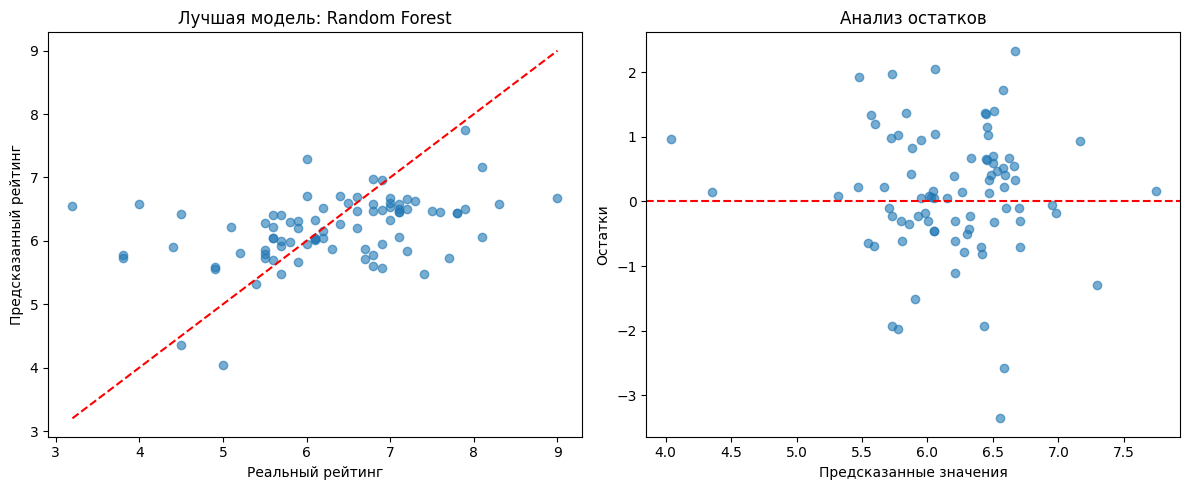

In [ ]:

# Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


#Загрузка данных

print("Загрузите файл movie_mania.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Размер данных:", df.shape)
print("Столбцы:", df.columns.tolist())


# Предобработка


# Удаляем ID-столбцы (imdbID и подобные)
df.drop(columns=['imdbID'], errors='ignore', inplace=True)

# Фильтруем только фильмы (не серии)
df = df[df['Type'] == 'movie'].copy()
df.drop(columns=['Type'], inplace=True)

#  Проверяем пропуски в ключевых столбцах и удаляем строки с ними
essential_cols = ['Year', 'Runtime (min)', 'Genre', 'Director',
                   'Language', 'Country', 'imdbVotes', 'imdbRating']
df.dropna(subset=essential_cols, inplace=True)

# Проверяем дубликаты
df.drop_duplicates(inplace=True)

if 'imdbVotes' in df.columns:
    df['imdbVotes'] = df['imdbVotes'].astype(str).str.replace(',', '').astype(float)

# Обработка категориальных признаков
# Жанры: разбиваем по запятой и создаём бинарные столбцы для топ-10 жанров
df['Genre_list'] = df['Genre'].str.split(', ')
all_genres = []
for lst in df['Genre_list']:
    all_genres.extend(lst)
top_genres = pd.Series(all_genres).value_counts().head(10).index.tolist()

for genre in top_genres:
    df[f'genre_{genre}'] = df['Genre_list'].apply(lambda x: 1 if genre in x else 0)

df.drop(columns=['Genre', 'Genre_list'], inplace=True)

# Частотное кодирование для Director, Language, Country
def freq_encode(col):
    freq = df[col].value_counts(normalize=True)
    return df[col].map(freq)

df['Director_enc'] = freq_encode('Director')
df['Language_enc'] = freq_encode('Language')
df['Country_enc'] = freq_encode('Country')
df.drop(columns=['Director', 'Language', 'Country'], inplace=True)

#  Масштабирование числовых признаков
num_cols = ['Year', 'Runtime (min)', 'imdbVotes']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#  Разделение на признаки и целевую переменную
X = df.drop(columns=['imdbRating', 'Title', 'Plot', 'Released', 'Writer', 'Actors'], errors='ignore')
y = df['imdbRating']

print("Число признаков после предобработки:", X.shape[1])


# Разбиение на train/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


# Обучение моделей

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name:20} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")


# Кросс-валидация (5-fold)

print("\nКросс-валидация (RMSE):")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    neg_mse = cross_val_score(model, X_train, y_train, cv=kf,
                              scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-neg_mse)
    print(f"{name:20} | mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")


# График предсказаний лучшей модели

best_name = min(results, key=lambda x: results[x]['RMSE'])
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальный рейтинг')
plt.ylabel('Предсказанный рейтинг')
plt.title(f'Лучшая модель: {best_name}')

plt.subplot(1,2,2)
residuals = y_test - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Анализ остатков')
plt.tight_layout()
plt.show()


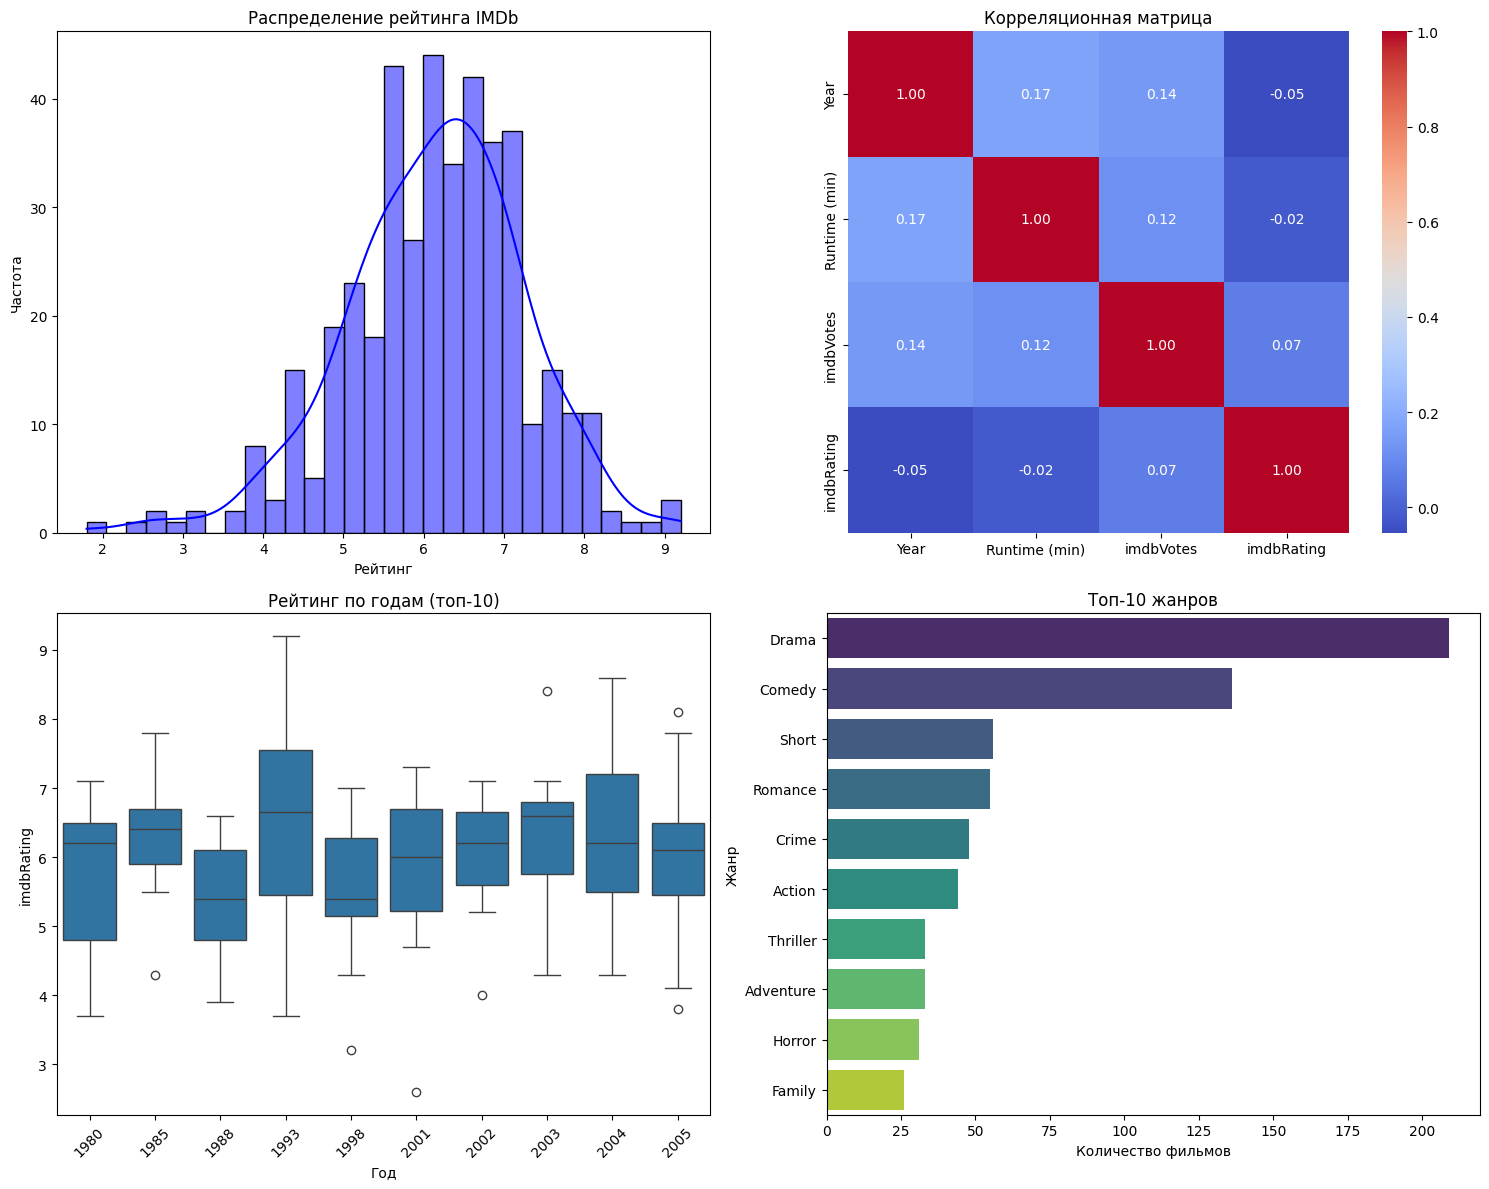

In [ ]:

# EDA


import matplotlib.pyplot as plt
import seaborn as sns


year_mean = scaler.mean_[0]      # среднее значение Year
year_scale = scaler.scale_[0]    # стандартное отклонение Year
df['Year_orig'] = (df['Year'] * year_scale + year_mean).astype(int)



plt.figure(figsize=(15, 12))

# 1. Распределение рейтинга
plt.subplot(2, 2, 1)
sns.histplot(df['imdbRating'], bins=30, kde=True, color='blue')
plt.title('Распределение рейтинга IMDb')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

# 2. Корреляционная матрица (только основные признаки + топ-3 жанра)
plt.subplot(2, 2, 2)
numeric_cols = ['Year', 'Runtime (min)', 'imdbVotes', 'imdbRating']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляционная матрица')

# 3. Рейтинг по годам (топ-10 годов) – используем восстановленные годы
plt.subplot(2, 2, 3)
top_years = df['Year_orig'].value_counts().head(10).index
df_top_years = df[df['Year_orig'].isin(top_years)]
sns.boxplot(data=df_top_years, x='Year_orig', y='imdbRating')
plt.xticks(rotation=45)
plt.title('Рейтинг по годам (топ-10)')
plt.xlabel('Год')

# 4. Топ-10 жанров по количеству фильмов
plt.subplot(2, 2, 4)
genre_counts = df[genre_cols].sum().sort_values(ascending=False).head(10)
sns.barplot(y=genre_counts.index.str.replace('genre_', ''), x=genre_counts.values, palette='viridis')
plt.title('Топ-10 жанров')
plt.xlabel('Количество фильмов')
plt.ylabel('Жанр')

plt.tight_layout()
plt.show()